<a href="https://colab.research.google.com/github/Mahiman001/Data-Science-learning-practice/blob/main/DECeSION_TREE_REGRESSOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
diabetes = load_diabetes()


In [ ]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [ ]:
df = pd.DataFrame(diabetes.data,columns= diabetes.feature_names)
df['target']= diabetes.target

In [ ]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
df.shape

(442, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [ ]:
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [ ]:
x = df.drop("target",axis =1)
y = df["target"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.33,random_state= 50)

In [ ]:
model = DecisionTreeRegressor(criterion="squared_error",max_depth=4,random_state=50)

In [ ]:
model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=50)

In [ ]:
y_pred =model.predict(x_test)

In [ ]:
y_pred

array([ 91.4957265 ,  91.4957265 , 154.        ,  91.4957265 ,
        91.4957265 ,  91.4957265 ,  91.4957265 , 243.25      ,
        91.4957265 ,  91.4957265 , 180.69565217,  91.4957265 ,
        91.4957265 ,  91.4957265 , 149.6       ,  91.4957265 ,
        91.4957265 ,  91.4957265 , 149.6       ,  91.4957265 ,
       158.11111111,  91.4957265 , 196.77777778, 149.6       ,
       149.6       , 102.77777778, 149.6       ,  91.4957265 ,
        91.4957265 , 154.        , 276.        , 180.69565217,
        91.4957265 ,  91.4957265 ,  91.4957265 ,  91.4957265 ,
       243.25      ,  91.4957265 , 149.6       , 243.25      ,
       149.6       , 243.25      , 149.6       , 216.        ,
       158.11111111, 149.6       , 102.77777778, 149.6       ,
       158.11111111,  91.4957265 , 158.11111111, 205.5       ,
       248.39130435, 149.6       ,  91.4957265 , 149.6       ,
        91.4957265 , 248.39130435, 149.6       , 154.        ,
       149.6       ,  91.4957265 ,  91.4957265 , 158.11

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("mae:", mae)
print("mse:", mse)
print("rmse:", rmse)
print("r2:", r2)

mae: 51.316494861104744
mse: 4263.113473976336
rmse: 65.29252234349914
r2: 0.228438492496834


In [ ]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

In [ ]:
print("trainingR2:", train_r2)
print("testingR2 :", test_r2)


trainingR2: 0.6127745503550242
testingR2 : 0.228438492496834


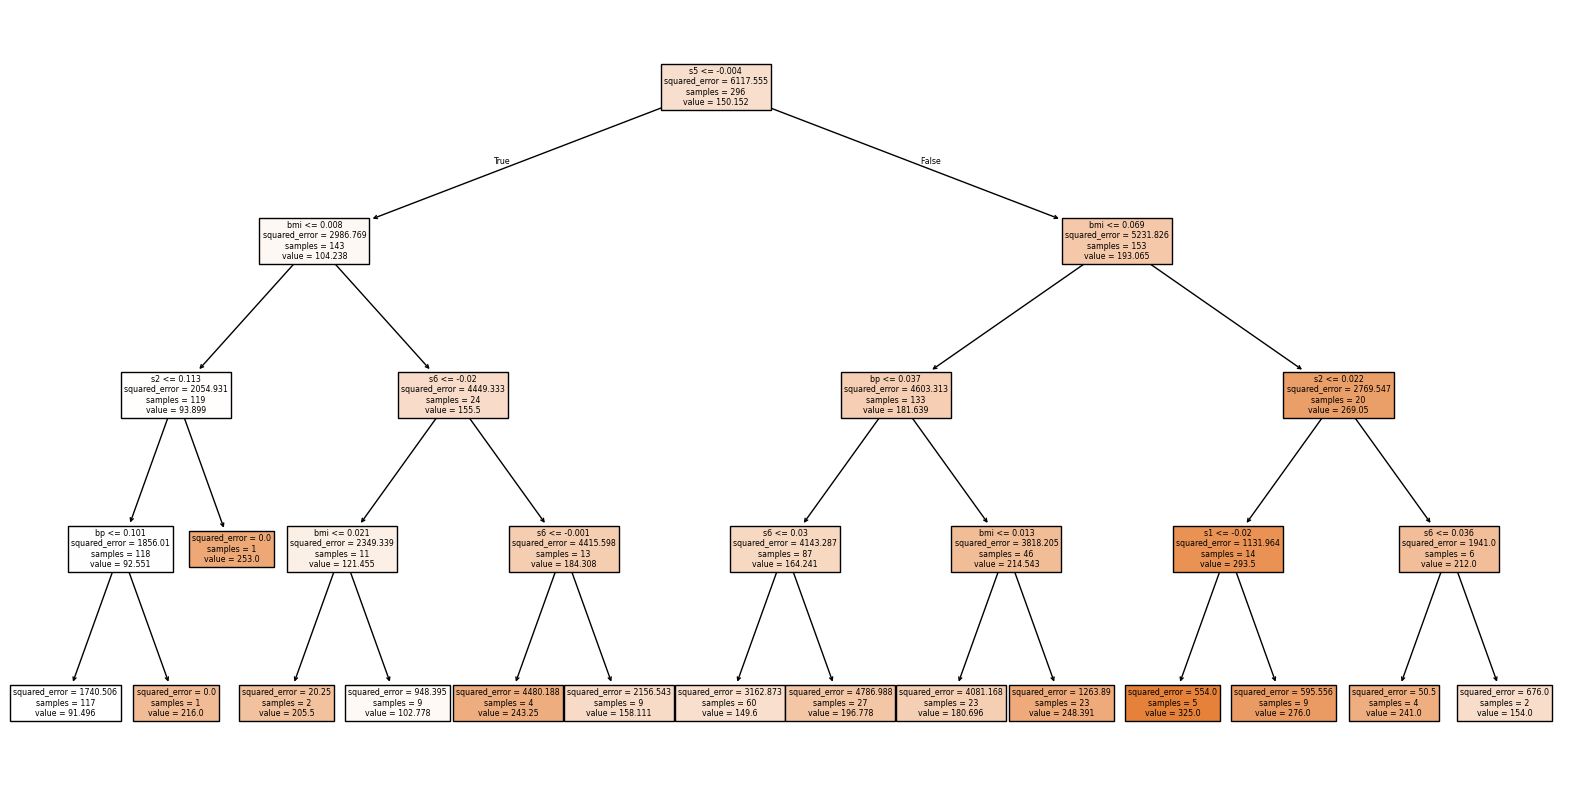

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=diabetes.feature_names,
    filled=True
)

plt.show()


# It does NOT say:
# "Which feature is most correlated with y?"

# It says:
# "Which feature + threshold creates the best split according to
# my criterion?"

In [ ]:
# It does NOT say:
# "Which feature is most correlated with y?"

# It says:
# "Which feature + threshold creates the best split according to
# my criterion?"

In [ ]:
# ##### the basic skeleton of  decesion tree is
# # Data
# X = df.drop("target", axis=1)
# y = df["target"]

# # Split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )

# # Model
# model = DecisionTreeRegressor(
#     max_depth=4,
#     random_state=42
# )

# # Train
# model.fit(X_train, y_train)

# # Predict
# y_pred = model.predict(X_test)

# # Evaluate
# print(mean_absolute_error(y_test, y_pred))
# print(mean_squared_error(y_test, y_pred))
# print(np.sqrt(mean_squared_error(y_test, y_pred)))
# print(r2_score(y_test, y_pred))

In [ ]:
      #            DECISION TREE
      #                  │
      #        Try feature + threshold
      #                  │
      #            Evaluate split
      #                  │
      #        ┌─────────┴─────────┐
      #        ↓                   ↓
      # CLASSIFICATION          REGRESSION
      #        ↓                   ↓
      # Gini / Entropy        Squared Error
      #        ↓                   ↓
      # Want LOW impurity     Want LOW error
      #        ↓                   ↓
      #  Pick best split      Pick best split